# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [1]:
!pip install icrawler

In [2]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [3]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [4]:
search_terms = {
    "america": "captain america",
    "thor": "thor odinson",
    "iron": "iron man"
}

for label, term in search_terms.items():
    download_images(term, f"data/avengers/{label}", n_total=100)

ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/captain-america-team-wallpapers_aG5uaWaUmZqaraWkpJRmZW1lrWdoaWU.jpg
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), 

Downloaded 22/100


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/captain-america-team-wallpapers_aG5uaWaUmZqaraWkpJRmZW1lrWdoaWU.jpg
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), 

Downloaded 43/100


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/captain-america-team-wallpapers_aG5uaWaUmZqaraWkpJRmZW1lrWdoaWU.jpg
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://www.pixel4k.com/wp-content/uploads/2018/12/captain-america-marvel-comics-4k-wallpaper_1544829426.jpg, error: HTTPSConnectionPool(host='www.pixel4k.com', port=443): Read timed out. (read timeout=5), 

...

Downloaded 91/100
Downloaded 100/100
Download complete!
Downloaded 11/100
Downloaded 22/100
Downloaded 33/100
Downloaded 44/100
Downloaded 55/100


ERROR:downloader:Response status code 403, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/11d8f897-a02c-4092-83e1-11c70c831c73/dguikew-ec8666fa-ee17-4c71-877f-2c7217774caa.jpg
ERROR:downloader:Response status code 403, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/7e2ebfd6-f71b-447e-b875-45a7190984a2/dfg258r-5e29abe5-bd68-4bd4-bf41-d08c8f94bcb1.jpg
ERROR:downloader:Response status code 404, file https://static.wikia.nocookie.net/marveldatabase/images/1/1f/Thor_Odinson_(Earth-TRN563)_from_Thor_Season_One_Vol_1_1.jpg
ERROR:downloader:Response status code 403, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/2bffe17a-8faf-4f07-b053-adb2c9ed63b1/dgvtgdo-a559bff2-af01-4c40-98e5-3fbe028f6e78.jpg
ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/2c4de332-4a0f-45a4-8d65-df33a0fd1156/dfr3vnk-0dc2ce7b-c09a-44ee-8050-460f4cf3bc1b.png/v1/fill/w_574,h_766,q_80,strp/thor_odinson_by_disorderlypictur

Downloaded 85/100
Downloaded 96/100
Downloaded 100/100
Download complete!
Downloaded 30/100


ERROR:downloader:Response status code 403, file https://i0.wp.com/insider-gaming.com/wp-content/uploads/2022/10/iron-man-playtesting.jpg


Downloaded 80/100
Downloaded 100/100
Download complete!


In [5]:
!pip install simple_image_download

INFO: pip is looking at multiple versions of simple-image-download to determine which version is compatible with other requirements. This could take a while.


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [6]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [7]:
from torch.utils.data import Dataset
from PIL import Image
import os

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_names = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        self.data = []
        for class_name in self.class_names:
            class_dir = os.path.join(self.root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith(('.png', '.jpg', '.jpeg')):
                    path = os.path.join(class_dir, filename)
                    item = (path, self.class_to_idx[class_name])
                    self.data.append(item)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [8]:
split_train_val(root_dir='data/avengers')

thor: 80 train, 20 val
america: 80 train, 20 val
iron: 80 train, 20 val


In [9]:
from torchvision import transforms

# Definir as transformações para os dados de treino e validação
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Criar os datasets com as transformações
train_dataset = CustomImageDataset(root_dir='data/avengers_split/train', transform=train_transform)
val_dataset = CustomImageDataset(root_dir='data/avengers_split/val', transform=val_transform)

# Criar os DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instanciar o modelo e movê-lo para a GPU se disponível
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=3).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

Epoch 1/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.61s/it]


Epoch 1/15 -> Train Loss: 2.7732, Train Accuracy: 40.42% | Val Loss: 1.1373, Val Accuracy: 33.33%


Epoch 2/15 [Val]: 100%|██████████| 2/2 [00:04<00:00,  2.00s/it]


Epoch 2/15 -> Train Loss: 0.9563, Train Accuracy: 43.75% | Val Loss: 0.8667, Val Accuracy: 68.33%


Epoch 3/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.63s/it]


...

Epoch 13/15 -> Train Loss: 0.0112, Train Accuracy: 99.58% | Val Loss: 0.0784, Val Accuracy: 95.00%


Epoch 14/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.67s/it]


Epoch 14/15 -> Train Loss: 0.0073, Train Accuracy: 100.00% | Val Loss: 0.0623, Val Accuracy: 96.67%


Epoch 15/15 [Val]: 100%|██████████| 2/2 [00:03<00:00,  1.69s/it]


Epoch 15/15 -> Train Loss: 0.0107, Train Accuracy: 99.58% | Val Loss: 0.2557, Val Accuracy: 91.67%


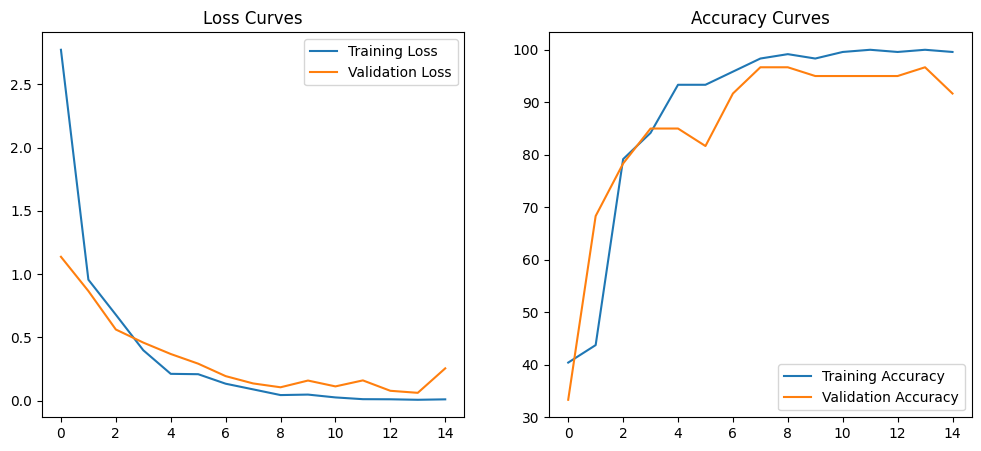

In [12]:
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# Função de custo e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Listas para armazenar o histórico de loss e acurácia
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 15

for epoch in range(num_epochs):
    # Treinamento
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validação
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} -> "
          f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

# Plotar as curvas de loss e acurácia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curves')
plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

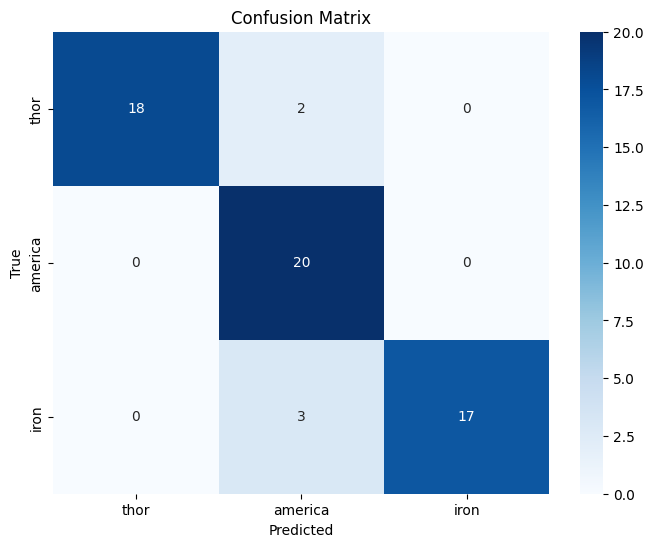


Classification Report:
              precision    recall  f1-score   support

        thor       1.00      0.90      0.95        20
     america       0.80      1.00      0.89        20
        iron       1.00      0.85      0.92        20

    accuracy                           0.92        60
   macro avg       0.93      0.92      0.92        60
weighted avg       0.93      0.92      0.92        60



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Obter predições e rótulos verdadeiros
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
class_names = val_dataset.class_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Relatório de Classificação
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))